## Summary

- 프로젝트명 : 마케팅 ABT 성과 분석
- 프로젝트유형 : ABT 결과 분석
- 시나리오 :
개선된 전략이 실제로 더 나은 성과를 가져올 수 있는지 통계적 검증 통해 효과 비교 및 마케팅 전략 수립

- 문제정의 : 고성과를 보인 마케팅 프로모션 식별

- 기대효과 :
    - 고성과 프로모션의 특성 이해  
    - 비즈니스 인사이트 확보 및 향후 전략 설계에 활용

- 해결방안 :
A/B 테스트 성과 비교를 통해 고성과/저성과 프로모션 도출

- 성과측정 :4개 기준 변수 기반 비교 분석 수행
    - MarketID  
    - MarketSize  
    - LocationID  
    - AgeOfStore

- 분석결과 / 제안
    - 1. 최우수 성과 보인 Promo3, 최저 성과 보인 Promo2의 성과 비교 진행
    - 2. 통계 측면에서 유의적 의미를 가지지 못하는 점을 확인하였으나, 이를 바탕으로 추가 ABT 진행을 위한 인사이트를 도출하였으며 이하 내용과 같습니다.

    - 프로모션 비교 : 3 vs 2 - Market ID 측면
        - Market ID 측면에서의 프로모션 2와 프로모션 3의 평균 매출 차이가 통계적으로 유의하지 않아, 유의미한 ABT 성과 비교가 어렵습니다.
        - 추가 ABT 검토 market은 Promo 3 고성과 보인 3, 7, 8, 9 를 권장 드립니다.

    - 프로모션 비교 : 3 vs 2 - MarketSize 측면
        - MarketSize 측면에서의 프로모션 2와 프로모션 3의 평균 매출 차이가 통계적으로 유의하지 않아, 유의미한 ABT 성과 비교가 어렵습니다.
        - 추가 ABT 검토 MarketSize 는 가장 고성과 Difference 보인 Medium 권장드립니다.

    - 프로모션 비교 : 3 vs 2 - LocationID 측면
        - LocationID별 복수의 Promotion 미집행 확인, LocationID별 Promotion 효율 비교가 어려운 점을 확인하여 생략

    - 프로모션 비교 : 3 vs 2 - AgeOfStore 측면
        - AgeOfStore 측면에서의 프로모션 2와 프로모션 3의 평균 매출 차이가 통계적으로 유의하지 않아, 유의미한 ABT 성과 비교가 어렵습니다.
        - 추가 ABT 검토 AgeOfStore 는 Promo_3 에서 우수한 성과와 Difference를 보인 5, 4, 8을 권장 드립니다.

- Meta data
    - MarketID : 시장 고유 식별자
    - MarketSize : 시장 규모 (판매량 기준의 크기)
    - LocationID : 매장 위치 고유 식별자
    - AgeOfStore : 매장의 운영 연차
    - Promotion : 적용된 프로모션 유형 (1, 2, 3 중 하나)
    - SalesInThousands : 특정 주차별 매출액 (단위: 천 달러)

> **데이터 살펴보기**

|Column|Description|
|:---|:---|
|MarketID|고유 식별자|
|MarketSize|판매량에 따른 시장 영역의 크기|
|LocationID|매장 위치의 고유 식별자|
|AgeOfStore|매장의 연령(설립된 지 몇 년인지)|
|Promotion|테스트된 세 가지 프로모션 중 하나|
|SalesInThousands|특정 LocationID, Promotion, 그리고 주에 대한 매출액 (천 단위)|




# Data import / Library import

In [ ]:
# Warnings 제거
import warnings
warnings.filterwarnings('ignore')


In [ ]:
# Data read
import pandas as pd
df = pd.read_csv('P_PJT05_DATA.csv')
df.head()

,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81


# EDA

In [ ]:
# shape
df.shape

(548, 7)

In [ ]:
# info
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MarketID          548 non-null    int64  
 1   MarketSize        548 non-null    object 
 2   LocationID        548 non-null    int64  
 3   AgeOfStore        548 non-null    int64  
 4   Promotion         548 non-null    int64  
 5   week              548 non-null    int64  
 6   SalesInThousands  548 non-null    float64
dtypes: float64(1), int64(5), object(1)
memory usage: 30.1+ KB


,0
MarketID,0
MarketSize,0
LocationID,0
AgeOfStore,0
Promotion,0
week,0
SalesInThousands,0


In [ ]:
# nunique()
df.nunique()

,0
MarketID,10
MarketSize,3
LocationID,137
AgeOfStore,25
Promotion,3
week,4
SalesInThousands,517


In [ ]:
# |MarketID|고유 식별자|
# |MarketSize|판매량에 따른 시장 영역의 크기|
# |LocationID|매장 위치의 고유 식별자|
# |AgeOfStore|매장의 연령(설립된 지 몇 년인지)|
# |Promotion|테스트된 세 가지 프로모션 중 하나|
# |SalesInThousands|특정 LocationID, Promotion, 그리고 주에 대한 매출액 (천 단위)|

for i in df.columns :
    print(i)
    display(df[i].value_counts())


MarketID


,count
MarketID,
3,88
10,80
7,60
5,60
6,60
1,52
8,48
9,40
4,36


MarketSize


,count
MarketSize,
Medium,320
Large,168
Small,60


LocationID


...

,count
Promotion,
3,188
2,188
1,172


week


,count
week,
1,137
2,137
3,137
4,137


SalesInThousands


,count
SalesInThousands,
51.09,3
47.22,3
51.72,2
36.17,2
49.08,2
...,...
61.25,1
54.49,1
43.69,1


# Analysis


## Overall
```
- 3가지 프로모션 중 어떠한 프로모션이 가장 성과가 좋았는가?

- 가장 성과가 좋았던 프로모션의 특징
	- 각 항목의 SalesInThousands 측정값 기준으로 성과를 판단
		- Market ID
		- MarketSize
		- LocationID
		- AgeOfStore
```

## Details

### 3가지 프로모션 중 어떠한 프로모션이 가장 성과가 좋았는가?

In [ ]:
# 가장 성과 좋은 프로모션은 총 매출 기준으로 3 > 1 > 2순 입니다.
# 평균, 중앙 매출값은 참고 수치입니다.
# 가장 성과가 좋았던 3번과 가장 저조한 성과를 보인 2번 프로모션 비교 통해 인사이트 확보 진행하겠습니다.
tmp = df.groupby(['Promotion'])['SalesInThousands'].agg(['sum', 'mean', 'median']).reset_index()
tmp

,Promotion,sum,mean,median
0,1,9993.03,58.099012,55.385
1,2,8897.93,47.329415,45.385
2,3,10408.52,55.364468,51.165


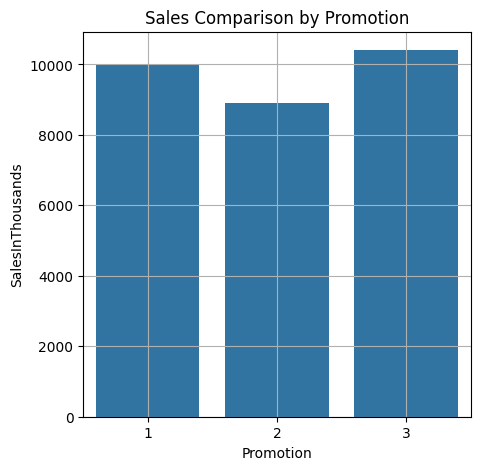

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
plt.figure(figsize=(5, 5))
sns.barplot(data=tmp, x='Promotion', y='sum')
plt.title("Sales Comparison by Promotion")
plt.ylabel("SalesInThousands")
plt.grid()
plt.show()

### 프로모션 비교 : 3 vs 2 - Market ID 측면


In [ ]:
tmp = df.groupby(['Promotion', 'MarketID'])['SalesInThousands'].agg('sum').reset_index()

In [ ]:
## Market ID 측면에서의 프로모션 2와 프로모션 3의 평균 매출 차이가 통계적으로 유의하지 않아, 유의미한 ABT 성과 비교가 어렵습니다.
## t = -0.125, p = 0.904

from scipy.stats import ttest_rel

# 피벗으로 구조 변경
pivot = tmp[tmp['Promotion'].isin([2, 3])].pivot(index='MarketID', columns='Promotion', values='SalesInThousands')
pivot.columns = ['Promo_2', 'Promo_3']

# NaN 제거
pivot_clean = pivot.dropna()

# 대응표본 t-검정
from scipy.stats import ttest_rel
t_stat, p_val = ttest_rel(pivot_clean['Promo_2'], pivot_clean['Promo_3'])
print(f"t = {t_stat:.3f}, p = {p_val:.3f}")

t = -0.125, p = 0.904


In [ ]:
pivot_clean['Difference'] = pivot_clean['Promo_3'] - pivot_clean['Promo_2']
pivot_clean.sort_values(by=['Promo_3', 'Difference'], ascending=[False, False])

,Promo_2,Promo_3,Difference
MarketID,,,
3,1910.21,3057.18,1146.97
7,629.79,1236.79,607.00
9,399.86,1037.75,637.89
5,1469.37,1016.78,-452.59
8,339.98,986.96,646.98
10,1950.40,648.61,-1301.79
6,782.31,588.24,-194.07
1,603.04,407.87,-195.17
4,812.97,208.47,-604.50


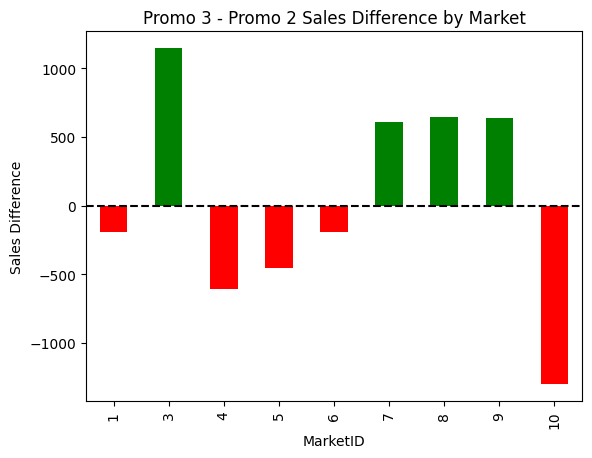

In [ ]:
## 추가 ABT 검토 market은 Promo 3 고성과 보인 3, 7, 8, 9 를 권장 드립니다.
pivot_clean['Difference'] = pivot_clean['Promo_3'] - pivot_clean['Promo_2']
pivot_clean['Difference'].plot(kind='bar', color=['green' if x > 0 else 'red' for x in pivot_clean['Difference']])
plt.axhline(0, color='black', linestyle='--')
plt.title("Promo 3 - Promo 2 Sales Difference by Market")
plt.ylabel("Sales Difference")
plt.show()

### 프로모션 비교 : 3 vs 2 - MarketSize 측면


In [ ]:
tmp = df.groupby(['Promotion', 'MarketSize'])['SalesInThousands'].agg('sum').reset_index()

In [ ]:
## MarketSize 측면에서의 프로모션 2와 프로모션 3의 평균 매출 차이가 통계적으로 유의하지 않아, 유의미한 ABT 성과 비교가 어렵습니다.
## t = -1.429, p = 0.289

from scipy.stats import ttest_rel

# 피벗으로 구조 변경
pivot = tmp[tmp['Promotion'].isin([2, 3])].pivot(index='MarketSize', columns='Promotion', values='SalesInThousands')
pivot.columns = ['Promo_2', 'Promo_3']

# NaN 제거
pivot_clean = pivot.dropna()

# 대응표본 t-검정
from scipy.stats import ttest_rel
t_stat, p_val = ttest_rel(pivot_clean['Promo_2'], pivot_clean['Promo_3'])
print(f"t = {t_stat:.3f}, p = {p_val:.3f}")

t = -1.429, p = 0.289


In [ ]:
## 추가 ABT 검토 MarketSize 는 가장 고성과 Difference 보인 Medium 권장드립니다.
pivot_clean['Difference'] = pivot_clean['Promo_3'] - pivot_clean['Promo_2']
pivot_clean.sort_values(by=['Promo_3', 'Difference'], ascending=[False, False])

,Promo_2,Promo_3,Difference
MarketSize,,,
Medium,4224.35,5274.39,1050.04
Large,3860.61,3705.79,-154.82
Small,812.97,1428.34,615.37


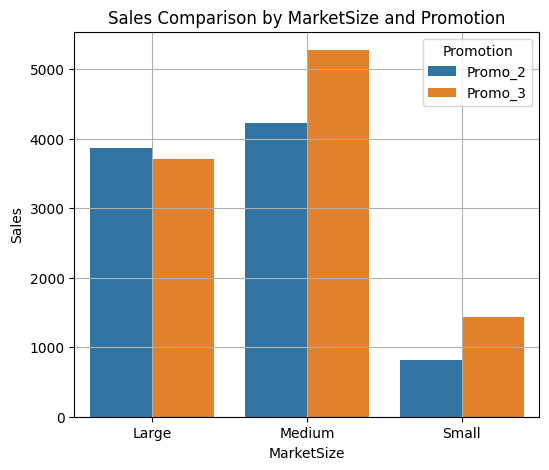

In [ ]:
pivot_clean_melted = pivot_clean.reset_index().melt(id_vars='MarketSize',
                                       value_vars=['Promo_2', 'Promo_3'],
                                       var_name='Promotion',
                                       value_name='Sales')
plt.figure(figsize=(6, 5))
sns.barplot(data=pivot_clean_melted, x='MarketSize', y='Sales', hue='Promotion')
plt.title("Sales Comparison by MarketSize and Promotion")
plt.grid()
plt.show()

### 프로모션 비교 : 3 vs 2 - LocationID 측면

In [ ]:
## LocationID별 복수의 Promotion 미집행 확인, LocationID별 Promotion 효율 비교가 어려운 점을 확인하여 생략
tmp = df[['LocationID', 'Promotion']].value_counts().reset_index()[['LocationID', 'Promotion']].value_counts().reset_index()
tmp[tmp['count'] != 1]


,LocationID,Promotion,count


### 프로모션 비교 : 3 vs 2 - AgeOfStore 측면

In [ ]:
tmp = df.groupby(['Promotion', 'AgeOfStore'])['SalesInThousands'].agg('sum').reset_index()
tmp[tmp['Promotion'].isin([3, 2])].head()

,Promotion,AgeOfStore,SalesInThousands
18,2,1,1787.16
19,2,2,345.39
20,2,3,535.86
21,2,4,640.01
22,2,5,353.41


In [ ]:
##AgeOfStore 측면에서의 프로모션 2와 프로모션 3의 평균 매출 차이가 통계적으로 유의하지 않음을 확인하였습니다.
## t = -0.375, p = 0.714

from scipy.stats import ttest_rel

# 피벗으로 구조 변경
pivot = tmp[tmp['Promotion'].isin([2, 3])].pivot(index='AgeOfStore', columns='Promotion', values='SalesInThousands')
pivot.columns = ['Promo_2', 'Promo_3']

# NaN 제거
pivot_clean = pivot.dropna()

# 대응표본 t-검정
from scipy.stats import ttest_rel
t_stat, p_val = ttest_rel(pivot_clean['Promo_2'], pivot_clean['Promo_3'])
print(f"t = {t_stat:.3f}, p = {p_val:.3f}")

t = -0.375, p = 0.714


In [ ]:
## 추가 ABT 검토 AgeOfStore 는 Promo_3 에서 우수한 성과와 Difference를 보인 5, 4, 8을 권장 드립니다.
pivot_clean['Difference'] = pivot_clean['Promo_3'] - pivot_clean['Promo_2']
pivot_clean.sort_values(by=['Promo_3', 'Difference'], ascending=[False, False]).head(5)

,Promo_2,Promo_3,Difference
AgeOfStore,,,
1,1787.16,1307.34,-479.82
5,353.41,1246.11,892.70
4,640.01,979.83,339.82
8,318.35,962.18,643.83
19,315.37,600.34,284.97


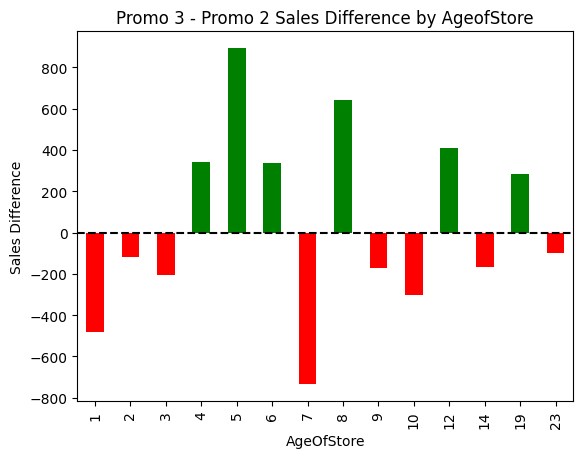

In [ ]:
pivot_clean['Difference'].plot(kind='bar', color=['green' if x > 0 else 'red' for x in pivot_clean['Difference']])
plt.axhline(0, color='black', linestyle='--')
plt.title("Promo 3 - Promo 2 Sales Difference by AgeofStore")
plt.ylabel("Sales Difference")
plt.show()

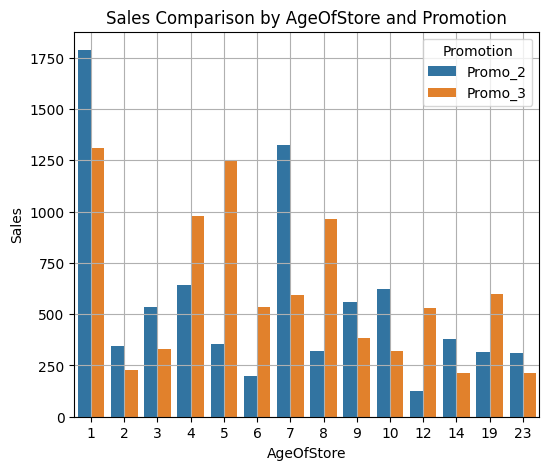

In [ ]:
pivot_clean_melted = pivot_clean.reset_index().melt(id_vars='AgeOfStore',
                                       value_vars=['Promo_2', 'Promo_3'],
                                       var_name='Promotion',
                                       value_name='Sales')
plt.figure(figsize=(6, 5))
sns.barplot(data=pivot_clean_melted, x='AgeOfStore', y='Sales', hue='Promotion')
plt.title("Sales Comparison by AgeOfStore and Promotion")
plt.grid()
plt.show()